# Movie Genre Classification

This project uses Natural Language Processing (NLP) and Machine Learning to classify movies into genres based on their plot descriptions.

## Techniques Used
- TF-IDF
- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes

## Dataset
The project uses the movie genre classification dataset provided for the internship.

In [48]:
import pandas as pd

train_data = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

train_data.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


## 2. Load and Explore the Dataset

The internship dataset contains movie titles, genres, and plot descriptions. The training data is loaded and inspected to understand its structure, genre distribution, and data quality.

### 2.1 Dataset Exploration

The dataset is explored by checking the number of movies, number of genres, genre distribution, and missing values.

In [49]:
print("Number of movies:", len(train_data))

print("\nNumber of genres:", train_data["GENRE"].nunique())

print("\nGenres and their counts:")
print(train_data["GENRE"].value_counts())

print("\nMissing values:")
print(train_data.isnull().sum())

Number of movies: 54214

Number of genres: 27

Genres and their counts:
GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64

Missing values:
ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64


## 3. Data Preparation

The movie description is used as the input feature, while the movie genre is used as the target variable for classification.

In [50]:
X = train_data["DESCRIPTION"]
y = train_data["GENRE"]

print("Input data:")
print(X.head())

print("\nTarget data:")
print(y.head())

Input data:
0    Listening in to a conversation between his doc...
1    A brother and sister with a past incestuous re...
2    As the bus empties the students for their fiel...
3    To help their unemployed father make ends meet...
4    The film's title refers not only to the un-rec...
Name: DESCRIPTION, dtype: str

Target data:
0       drama
1    thriller
2       adult
3       drama
4       drama
Name: GENRE, dtype: str


## 4. TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) is used to convert the movie plot descriptions into numerical features that machine learning algorithms can understand.

Common English stop words are removed, and up to 50,000 features are considered.

The TF-IDF vectorizer is fitted only on the training data and then used to transform the testing data to avoid data leakage.

### 4.1 Convert Text into Numerical Features

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 43371
Testing samples: 10843


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

## 5. Logistic Regression Model

Logistic Regression is used as the primary classification algorithm to predict the movie genre from the TF-IDF features.

The model is trained using the TF-IDF representation of the training movie descriptions and their corresponding genres.

### 5.1 Generate Predictions

The trained Logistic Regression model is used to predict genres for the unseen test descriptions.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
['short' 'horror' 'adult' 'drama' 'drama' 'short' 'documentary' 'drama'
 'comedy' 'drama']


## 6. Model Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, and F1-score. These metrics help measure how well the model predicts movie genres on unseen data.

### 6.1 Confusion Matrix

A confusion matrix is used to analyze correct and incorrect predictions for each movie genre. The diagonal values represent correct predictions, while values outside the diagonal represent classification errors.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5806511113160564

Classification Report:
              precision    recall  f1-score   support

      action       0.57      0.23      0.33       263
       adult       0.71      0.25      0.36       118
   adventure       0.62      0.10      0.17       155
   animation       0.75      0.03      0.06       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.59      0.56      1490
       crime       0.50      0.01      0.02       101
 documentary       0.65      0.87      0.74      2619
       drama       0.54      0.80      0.64      2723
      family       0.56      0.06      0.11       157
     fantasy       0.00      0.00      0.00        65
   game-show       1.00      0.33      0.50        39
     history       0.00      0.00      0.00        49
      horror       0.70      0.56      0.62       441
       music       0.70      0.32      0.43       146
     musical       1.00      0.02      0.04        55
     mystery       0.00     

c:\Users\Mohammed Talha Jalal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mohammed Talha Jalal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mohammed Talha Jalal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

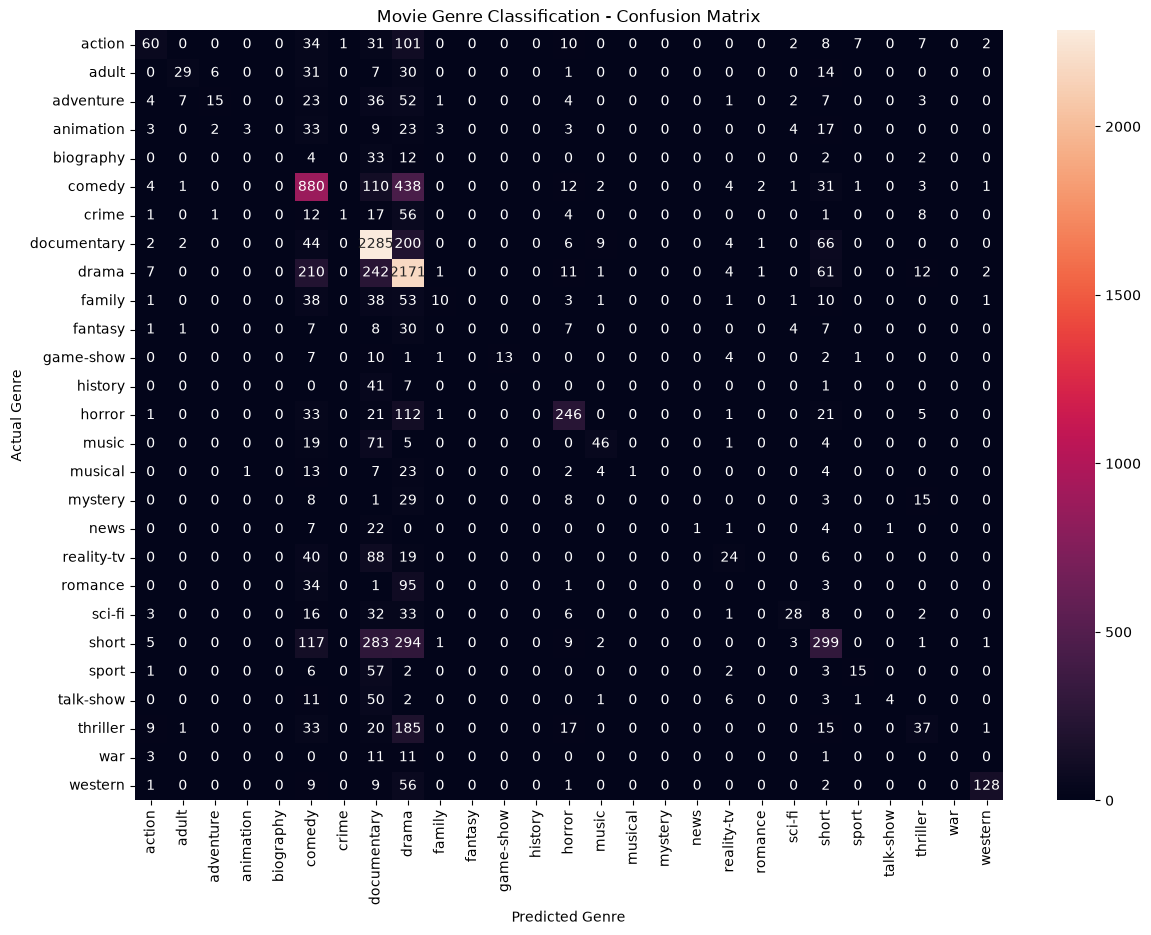

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Movie Genre Classification - Confusion Matrix")
plt.show()

### 6.2 Linear SVM

A Linear Support Vector Machine (SVM) is trained using the same TF-IDF features. Its performance is compared with Logistic Regression.

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

print("SVM model training completed!")

SVM model training completed!


In [ ]:
svm_pred = svm_model.predict(X_test_tfidf)

print("SVM predictions completed!")
print(svm_pred[:10])


SVM predictions completed!
['short' 'horror' 'adult' 'drama' 'comedy' 'short' 'documentary' 'horror'
 'comedy' 'horror']


In [ ]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)


SVM Accuracy: 0.5733653048049433


### 6.3 Naive Bayes

Multinomial Naive Bayes is trained using the TF-IDF features and evaluated to compare its performance with Logistic Regression and Linear SVM.


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model training completed!")

Naive Bayes model training completed!


In [ ]:
nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes predictions completed!")
print(nb_pred[:10])

Naive Bayes predictions completed!
['documentary' 'drama' 'comedy' 'drama' 'drama' 'drama' 'documentary'
 'drama' 'drama' 'drama']


In [ ]:
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.4555012450428848


### 6.4 Model Comparison

The performance of Logistic Regression, Linear SVM, and Multinomial Naive Bayes is compared using accuracy.

- Logistic Regression: 58.07%
- Linear SVM: 57.34%
- Multinomial Naive Bayes: 45.55%

Logistic Regression achieved the highest accuracy and was selected as the final model.

In [ ]:
test_data = pd.read_csv(
    "test_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID", "TITLE", "DESCRIPTION"]
)

print("Number of test movies:", len(test_data))
test_data.head()

Number of test movies: 54200


,ID,TITLE,DESCRIPTION
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apart..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty chi..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family o...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with his..."
4,5,Er nu zhai (1955),Before he was known internationally as a marti...


In [ ]:
test_descriptions = test_data["DESCRIPTION"]

test_data_tfidf = tfidf.transform(test_descriptions)

print("Test data TF-IDF shape:", test_data_tfidf.shape)

Test data TF-IDF shape: (54200, 50000)


In [ ]:
test_predictions = model.predict(test_data_tfidf)

print("Predictions for internship test data completed!")
print(test_predictions[:20])

Predictions for internship test data completed!
['drama' 'drama' 'documentary' 'drama' 'drama' 'drama' 'drama' 'comedy'
 'documentary' 'drama' 'drama' 'drama' 'drama' 'documentary' 'short'
 'documentary' 'comedy' 'western' 'documentary' 'drama']


## 7. Final Test and Prediction

The final Logistic Regression model is applied to the separate test dataset provided by the internship. The predictions are then compared with the official test solutions to evaluate the model's performance on unseen data.

In [ ]:
test_solution = pd.read_csv(
    "test_data_solution.txt",
    sep=" ::: ",
    engine="python",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

print("Number of solution records:", len(test_solution))
test_solution.head()

Number of solution records: 54200


,ID,TITLE,GENRE,DESCRIPTION
0,1,Edgar's Lunch (1998),thriller,"L.R. Brane loves his life - his car, his apart..."
1,2,La guerra de papá (1977),comedy,"Spain, March 1964: Quico is a very naughty chi..."
2,3,Off the Beaten Track (2010),documentary,One year in the life of Albin and his family o...
3,4,Meu Amigo Hindu (2015),drama,"His father has died, he hasn't spoken with his..."
4,5,Er nu zhai (1955),drama,Before he was known internationally as a marti...


### 7.1 Final Internship Test Accuracy

The predictions generated for the internship test dataset are compared with the official genres provided in the test solution file.


In [ ]:
final_accuracy = accuracy_score(
    test_solution["GENRE"],
    test_predictions
)

print("Final Internship Test Accuracy:", final_accuracy)
print("Final Internship Test Accuracy (%):", final_accuracy * 100)


Final Internship Test Accuracy: 0.5805535055350554
Final Internship Test Accuracy (%): 58.055350553505534


### 7.2 Predict Genre for a New Movie Plot

The final model is tested on a new movie plot that was not included in the training dataset. The same TF-IDF vectorizer is used to transform the text before making the genre prediction.

In [ ]:
new_plot = [
    "A detective investigates a series of mysterious murders while trying to find the killer before another victim is found."
]

new_plot_tfidf = tfidf.transform(new_plot)

prediction = model.predict(new_plot_tfidf)

print("Predicted Genre:", prediction[0])

Predicted Genre: thriller


## 8. Conclusion

A machine learning model was developed to classify movie genres based on plot descriptions using Natural Language Processing (NLP).

TF-IDF was used to convert the movie descriptions into numerical features. Three machine learning algorithms were evaluated: Logistic Regression, Linear SVM, and Multinomial Naive Bayes.

Among the three models, Logistic Regression achieved the highest validation accuracy of 58.07%, compared with 57.34% for Linear SVM and 45.55% for Multinomial Naive Bayes.

The final Logistic Regression model achieved an accuracy of 58.06% on the separate test dataset provided with the internship.

The model was also successfully tested on a new movie plot and predicted its genre as "thriller".

### Final Model
TF-IDF + Logistic Regression

### Final Internship Test Accuracy
58.06%
